<a href="https://colab.research.google.com/github/Stellamatt0303/FINTECH-P2-MATTEUCCI-CHERVENKA-/blob/main/FINA4075_P2_StrategyLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINA 4075/5075 — Project 0 Starter Notebook (Fall 2026)

**Before running anything:** File → **Save a copy in Drive**, then Runtime → Change runtime type → **Runtime version 2026.07** (Rule 0).

Follow the Project 0 Detailed Student Instructions (D2L). Run cells top to bottom; finish with **Runtime → Restart session and run all** — it must complete with no errors before you submit.

In [1]:
# Cell 1 — mount Drive (Rule 1)
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Cell 2 — create the course folder
import os
P0 = "/content/drive/MyDrive/FINA4075/P0"
os.makedirs(P0, exist_ok=True)
print("Folder ready:", P0)

Folder ready: /content/drive/MyDrive/FINA4075/P0


In [3]:
# Cell 3 — pinned setup (Rule 2; -q omitted in P0 on purpose)
# Official pinned line (Fall 2026), as posted in D2L (Rule 2).
%pip install yfinance==0.2.66

In [4]:
# Cell 4 — environment stamp (Rule 0)
import sys, pandas as pd, numpy as np, matplotlib, yfinance as yf
print(sys.version)
print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| yfinance", yf.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | yfinance 0.2.66


### Project 2 Setup & File Verification

In [5]:
# Project 2 — locate the required files
from pathlib import Path

P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")

panel_path = P2_DIR / "panel_returns_2026-08-31.csv"
ticker_path = P2_DIR / "P2_ticker_list_2026-08-31.csv"

print("Project 2 folder:", P2_DIR)
print("Panel exists:", panel_path.exists())
print("Ticker list exists:", ticker_path.exists())

assert panel_path.exists(), f"Panel file not found: {panel_path}"
assert ticker_path.exists(), f"Ticker-list file not found: {ticker_path}"

Project 2 folder: /content/drive/MyDrive/FINA4075/P2
Panel exists: True
Ticker list exists: True


In [6]:
# Project 2 — load and validate the panel
panel = pd.read_csv(panel_path, index_col=0)

print("Panel shape:", panel.shape)

assert panel.shape == (92, 200), (
    f"Expected panel shape (92, 200), but received {panel.shape}"
)

display(panel.head())

Panel shape: (92, 200)


,NYT,MTCH,SIRI,MSGS,SNAP,LUMN,TTD,NXST,IRDM,TDS,...,NJR,OGS,SR,NWE,OTTR,AWR,CPK,AVA,CWT,MGEE
date,,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.155454,0.250643,0.021016,0.038102,0.212341,0.011222,0.229364,0.061420,0.050406,0.113092,...,0.061967,0.032036,0.071409,0.075201,-0.023973,0.010143,0.114022,-0.014830,0.039026,0.072548
2019-02-28,0.277713,0.035334,0.019229,0.036848,0.467066,-0.139035,0.384497,0.177107,0.098556,-0.115130,...,-0.002062,0.058599,-0.000630,0.072446,0.045157,0.054536,-0.006183,-0.025312,0.054622,-0.000805
2019-03-29,0.000000,0.022210,-0.043845,0.017318,0.124490,-0.072118,0.002076,0.108872,0.241897,-0.036221,...,0.034735,0.029844,0.045251,0.035713,-0.009149,0.002391,0.017360,0.005197,0.043444,0.063361
2019-04-30,0.010640,0.066949,0.024691,0.065875,0.010889,-0.047540,0.118868,0.080096,0.038578,0.037423,...,0.005824,-0.005728,0.023089,-0.007954,0.029707,-0.001824,0.015678,0.062038,-0.071665,-0.002648
2019-05-31,-0.040121,0.136589,-0.084144,-0.053130,0.067325,-0.063047,-0.102357,-0.140814,-0.219592,-0.096298,...,-0.052516,-0.005223,-0.010334,0.015605,-0.025094,0.028772,-0.020077,-0.022931,-0.019313,-0.017895


In [7]:
# Project 2 — calculate and verify the panel SHA-256
from pathlib import Path
import hashlib

# Define the file location
P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")
panel_path = P2_DIR / "panel_returns_2026-08-31.csv"

# Confirm the file exists
assert panel_path.exists(), f"Panel file not found: {panel_path}"

def sha256_file(file_path):
    sha = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            sha.update(block)

    return sha.hexdigest()

actual_hash = sha256_file(panel_path)
expected_hash = "c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b"

print("Actual SHA-256:  ", actual_hash)
print("Expected SHA-256:", expected_hash)

assert actual_hash.lower() == expected_hash.lower(), (
    "SHA-256 does not match the Data Dictionary."
)

print("SHA-256 verified successfully.")

Actual SHA-256:   c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b
Expected SHA-256: c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b
SHA-256 verified successfully.


In [10]:
# Pre-commit exploration — load company information
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")
company_path = P2_DIR / "FINA 4075-5075 Project 2 - Company List - Fall 2026.xlsx"

# Check if file exists; if not, raise a helpful instruction message
if not company_path.exists():
    msg = (
        f"\n{'='*70}\n"
        f"ERROR: The file '{company_path.name}' is missing!\n\n"
        f"Please follow these steps to fix this error:\n"
        f"1. Download the Excel workbook from D2L.\n"
        f"2. Upload it to your Google Drive folder: FINA4075/P2/\n"
        f"3. Rerun this cell once the upload is finished.\n"
        f"{'='*70}\n"
    )
    raise FileNotFoundError(msg)

companies = pd.read_excel(company_path, sheet_name="Company List")

# Work with a separate copy; do not change the original CSV
explore_returns = panel.copy()
explore_returns.index = pd.to_datetime(explore_returns.index)
explore_returns = explore_returns.sort_index()
explore_returns.columns = explore_returns.columns.str.strip()

companies["Ticker"] = companies["Ticker"].str.strip()
assert companies["Ticker"].is_unique, "Duplicate tickers in company list."

company_info = companies.set_index("Ticker")

missing_tickers = explore_returns.columns.difference(company_info.index)
assert len(missing_tickers) == 0, f"Unmatched tickers: {missing_tickers.tolist()}"

print("Company list loaded:", len(companies), "companies")
print("Sectors:", companies["Sector"].nunique())
print("Missing return values:", explore_returns.isna().sum().sum())

display(companies[["Ticker", "Company", "Sector"]].head())

Company list loaded: 200 companies
Sectors: 11
Missing return values: 0


,Ticker,Company,Sector
0,NYT,The New York Times Company,Communication Services
1,MTCH,"Match Group, Inc.",Communication Services
2,SIRI,Sirius XM Holdings Inc.,Communication Services
3,MSGS,Madison Square Garden Sports Corp.,Communication Services
4,SNAP,Snap Inc.,Communication Services


In [11]:
# Historical summary statistics for all 200 stocks
stock_summary = pd.DataFrame({
    "Mean monthly return": explore_returns.mean(),
    "Monthly volatility": explore_returns.std(ddof=1),
    "Worst month": explore_returns.min(),
    "Best month": explore_returns.max(),
    "Months available": explore_returns.count()
})

stock_summary = stock_summary.join(company_info[["Company", "Sector"]])

display(
    stock_summary.head(10).style.format({
        "Mean monthly return": "{:.2%}",
        "Monthly volatility": "{:.2%}",
        "Worst month": "{:.2%}",
        "Best month": "{:.2%}"
    })
)

print("Summary across the 200 stocks:")
display(stock_summary.iloc[:, :5].describe().round(4))

,Mean monthly return,Monthly volatility,Worst month,Best month,Months available,Company,Sector
NYT,1.74%,9.74%,-19.11%,27.77%,92,The New York Times Company,Communication Services
MTCH,0.66%,11.64%,-27.21%,30.44%,92,"Match Group, Inc.",Communication Services
SIRI,-0.08%,9.50%,-28.12%,27.25%,92,Sirius XM Holdings Inc.,Communication Services
MSGS,1.13%,7.99%,-21.06%,19.97%,92,Madison Square Garden Sports Corp.,Communication Services
SNAP,1.72%,18.45%,-50.42%,50.86%,92,Snap Inc.,Communication Services
LUMN,1.82%,26.71%,-35.24%,186.36%,92,"Lumen Technologies, Inc.",Communication Services
TTD,1.82%,18.50%,-40.75%,59.07%,92,"The Trade Desk, Inc.",Communication Services
NXST,1.85%,11.13%,-49.79%,28.61%,92,"Nexstar Media Group, Inc.",Communication Services
IRDM,1.87%,12.66%,-29.25%,40.84%,92,Iridium Communications Inc.,Communication Services
TDS,1.78%,21.25%,-38.00%,167.96%,92,"Telephone and Data Systems, Inc.",Communication Services


Summary across the 200 stocks:


,Mean monthly return,Monthly volatility,Worst month,Best month,Months available
count,200.0000,200.0000,200.0000,200.0000,200.0
mean,0.0152,0.1129,-0.3058,0.4041,92.0
std,0.0096,0.0463,0.1424,0.3228,0.0
min,-0.0008,0.0539,-0.8143,0.1179,92.0
25%,0.0082,0.0785,-0.3804,0.2216,92.0
50%,0.0136,0.1028,-0.2805,0.3087,92.0
75%,0.0188,0.1323,-0.1891,0.4426,92.0
max,0.0575,0.3561,-0.1099,2.3396,92.0


In [12]:
# Signal for each portfolio month:
# standard deviation of the previous 36 months, excluding that month
low_vol_signal = (
    explore_returns.shift(1)
    .rolling(window=36, min_periods=36)
    .std(ddof=1)
)

portfolio_month = explore_returns.index[-1]
latest_signal = low_vol_signal.iloc[-1].dropna()

assert len(latest_signal) >= 20, "Not enough stocks with 36 months of data."

ranking = latest_signal.rename("Monthly volatility").to_frame()
ranking.index.name = "Ticker"
ranking = ranking.reset_index()

# Lowest volatility first; alphabetical ticker breaks ties
ranking = ranking.sort_values(
    ["Monthly volatility", "Ticker"],
    ascending=[True, True]
)

selected20 = (
    ranking.head(20)
    .set_index("Ticker")
    .join(company_info[["Company", "Sector"]])
)

selected20["Annualized volatility"] = (
    selected20["Monthly volatility"] * np.sqrt(12)
)
selected20["Weight"] = 1 / 20

print("Illustrative portfolio month:", portfolio_month.strftime("%B %Y"))
print(
    "Signal uses:",
    explore_returns.index[-37].strftime("%B %Y"),
    "through",
    explore_returns.index[-2].strftime("%B %Y")
)

display(selected20.style.format({
    "Monthly volatility": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Weight": "{:.0%}"
}))

Illustrative portfolio month: August 2026
Signal uses: August 2023 through July 2026


,Monthly volatility,Company,Sector,Annualized volatility,Weight
Ticker,,,,,
AWR,4.30%,American States Water Company,Utilities,14.88%,5%
OGE,4.59%,OGE Energy Corp.,Utilities,15.89%,5%
KRG,4.69%,Kite Realty Group Trust,Real Estate,16.24%,5%
NJR,5.02%,New Jersey Resources Corporation,Utilities,17.39%,5%
IDA,5.02%,"IDACORP, Inc.",Utilities,17.39%,5%
POR,5.02%,Portland General Electric Company,Utilities,17.40%,5%
ADC,5.07%,Agree Realty Corporation,Real Estate,17.58%,5%
CWT,5.19%,California Water Service Group,Utilities,17.97%,5%
BRX,5.23%,Brixmor Property Group Inc.,Real Estate,18.13%,5%


,Panel stocks,Selected stocks,Panel weight,Selected weight
Sector,,,,
Communication Services,18,0,9.0%,0%
Consumer Discretionary,18,0,9.0%,0%
Consumer Staples,18,2,9.0%,10%
Energy,18,0,9.0%,0%
Financials,19,0,9.5%,0%
Health Care,18,0,9.0%,0%
Industrials,19,0,9.5%,0%
Information Technology,18,0,9.0%,0%
Materials,18,0,9.0%,0%


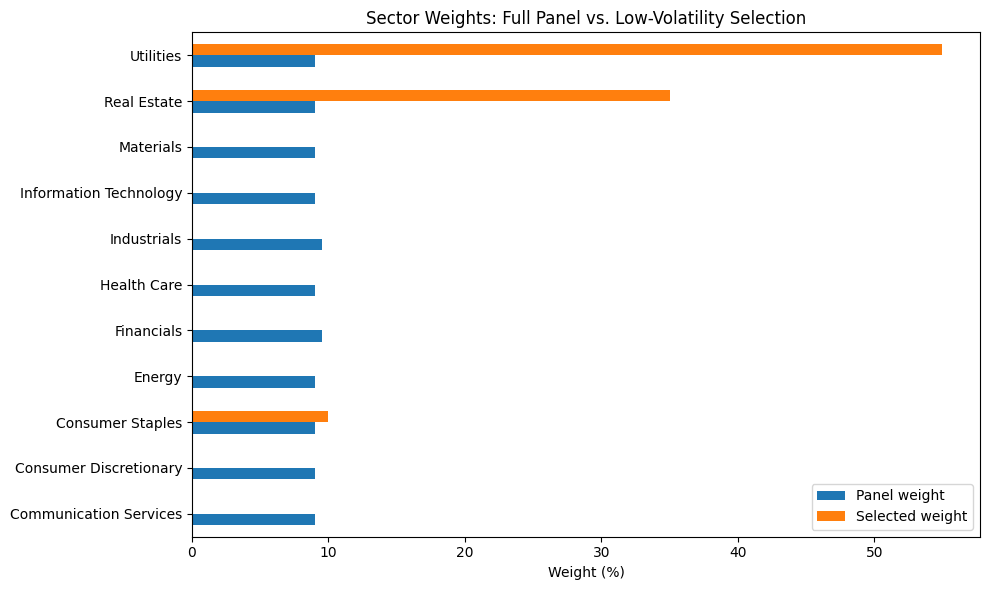

In [13]:
# Compare selected portfolio weights with full-panel sector weights
full_sector_counts = (
    company_info.loc[explore_returns.columns, "Sector"]
    .value_counts()
)

selected_sector_counts = selected20["Sector"].value_counts()

sector_comparison = pd.DataFrame({
    "Panel stocks": full_sector_counts,
    "Selected stocks": selected_sector_counts
}).fillna(0).astype(int).sort_index()

sector_comparison["Panel weight"] = (
    sector_comparison["Panel stocks"] / explore_returns.shape[1]
)
sector_comparison["Selected weight"] = (
    sector_comparison["Selected stocks"] / 20
)

display(sector_comparison.style.format({
    "Panel weight": "{:.1%}",
    "Selected weight": "{:.0%}"
}))

# Display weights as percentages
ax = (
    sector_comparison[["Panel weight", "Selected weight"]] * 100
).plot.barh(figsize=(10, 6))

ax.set_title("Sector Weights: Full Panel vs. Low-Volatility Selection")
ax.set_xlabel("Weight (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### August 31, 2026 Briefing Table
This section constructs the performance briefing table for all 200 stocks. It calculates:
- **1M**: Return for the most recent month (August 2026)
- **3M**: Cumulative return over the last 3 months (June 2026 through August 2026)
- **12M**: Cumulative return over the last 12 months (September 2025 through August 2026)

In [15]:
import pandas as pd
import numpy as np

# Create a separate working copy
briefing_returns = panel.copy()
briefing_returns.index = pd.to_datetime(briefing_returns.index)
briefing_returns = briefing_returns.sort_index()

# Include only information available through August 2026
as_of = pd.Timestamp("2026-08-31")
briefing_returns = briefing_returns.loc[
    briefing_returns.index.to_period("M") <= as_of.to_period("M")
]

# Validate dates and data
months = briefing_returns.index.to_period("M")
expected_months = pd.period_range("2025-09", "2026-08", freq="M")

assert months[-12:].equals(expected_months), (
    "The last 12 rows must be September 2025 through August 2026."
)
assert briefing_returns.shape[1] == 200
assert np.isfinite(briefing_returns.iloc[-12:].to_numpy()).all(), (
    "Missing or non-finite returns in the briefing window."
)

# Calculate compounded trailing returns
briefing_table = pd.DataFrame({
    "1M": briefing_returns.iloc[-1],
    "3M": (1 + briefing_returns.iloc[-3:]).prod() - 1,
    "12M": (1 + briefing_returns.iloc[-12:]).prod() - 1
})

# Add company information and explicitly name the ticker index
briefing_table = briefing_table.join(
    company_info[["Company", "Sector"]]
)
briefing_table.index.name = "Ticker"

briefing_table = (
    briefing_table.reset_index()
    [["Ticker", "Company", "Sector", "1M", "3M", "12M"]]
    .sort_values("Ticker")
)

assert len(briefing_table) == 200
assert briefing_table["Ticker"].is_unique
assert not briefing_table.isna().any().any(), (
    "Missing company information or returns."
)

# Print a plain-text table for copying into the LLM chat
lines = [
    "As of: 2026-08-31",
    "Ticker | Company | Sector | 1M | 3M | 12M"
]

for row in briefing_table.itertuples(index=False):
    lines.append(
        f"{row.Ticker} | {row.Company} | {row.Sector} | "
        f"{row[3]:.2%} | {row[4]:.2%} | {row[5]:.2%}"
    )

briefing_text = "\n".join(lines)
print(briefing_text)

As of: 2026-08-31
Ticker | Company | Sector | 1M | 3M | 12M
ACAD | ACADIA Pharmaceuticals Inc. | Health Care | 11.75% | 33.47% | 11.24%
ACM | AECOM | Industrials | -6.85% | -2.36% | -45.29%
AD | Array Digital Infrastructure, Inc. | Communication Services | 5.22% | -8.74% | 3.88%
ADC | Agree Realty Corporation | Real Estate | -6.79% | -1.53% | 3.63%
AGCO | AGCO Corporation | Industrials | 16.16% | 5.69% | 10.50%
ALK | Alaska Air Group, Inc. | Industrials | -12.90% | -10.19% | -34.17%
AMG | Affiliated Managers Group, Inc. | Financials | 0.40% | 21.58% | 63.79%
AMRX | Amneal Pharmaceuticals, Inc. | Health Care | -4.64% | 32.65% | 82.74%
AOS | A. O. Smith Corporation | Industrials | -1.66% | 4.88% | -15.21%
APPF | AppFolio, Inc. | Information Technology | 29.98% | 45.32% | -15.56%
AROC | Archrock, Inc. | Energy | -11.28% | -5.26% | 30.87%
ASH | Ashland Inc. | Materials | 0.99% | 27.57% | 33.48%
AVA | Avista Corporation | Utilities | -6.96% | -9.25% | 6.73%
AVNT | Avient Corporation | Mater

Runtime - Restart session and run all - Confirm the panel shape is (92, 200) and the SHA-256 verification succeeds.